# Imports

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random
import csv
from typing import Tuple

# Import proto-language modules
from proto_language.language.core import (
    Constraint,
    Construct,
    Segment,
    Sequence,
    Program,
)
from proto_language.language.constraint import (
    structure_plddt_constraint,
    structure_ptm_constraint,
    protein_symmetry_ring_constraint,
    protein_globularity_constraint,
    max_homopolymer_constraint,
)
from proto_language.language.optimizer import (
    MCMCOptimizer,
    MCMCOptimizerConfig,
)
from proto_language.language.generator import (
    ESM2Generator,
    ESM2GeneratorConfig,
)

random.seed(42)
np.random.seed(42)

# Write Program

In [ ]:
# Configuration parameters
MONOMER_LENGTH = 30
N_SYMMETRIC_UNITS = 3
N_STEPS = 2000

#######################
## Segments ##
#######################

segment = Segment(
    length=MONOMER_LENGTH,
    sequence_type="protein",
)

################
## Construct ##
################

construct = Construct([segment])

################
## Generator ##
################

# Initialize ESM2 protein language model generator
esm2_gen_config = ESM2GeneratorConfig()
esm2_gen = ESM2Generator(esm2_gen_config)

esm2_gen.assign(segment)

#################
## Constraints ##
#################

# ESMFold pLDDT constraint (protein confidence/quality)
esmfold_plddt = Constraint(
    inputs=[segment for _ in range(N_SYMMETRIC_UNITS)],
    function=structure_plddt_constraint,
    function_config={"structure_tool": "esmfold"},
    weight=20,
)

esmfold_ptm = Constraint(
    inputs=[segment for _ in range(N_SYMMETRIC_UNITS)],
    function=structure_ptm_constraint,
    function_config={"structure_tool": "esmfold"},
    weight=20,
)

symmetry = Constraint(
    inputs=[segment],
    function=protein_symmetry_ring_constraint,
    function_config={
        "n_replications": N_SYMMETRIC_UNITS,
        "all_to_all_protomer_symmetry": True,
    },
)

globularity = Constraint(
    inputs=[segment],
    function=protein_globularity_constraint,
    function_config={"n_replications": N_SYMMETRIC_UNITS},
)

homopolymer = Constraint(
    inputs=[segment],
    function=max_homopolymer_constraint,
    function_config={"max_length": 2},
    weight=20,
)

#############
## Optimizer & Program ##
#############

def custom_logging(step: int, outputs: Tuple[Segment]) -> None:
    output_sequence: Sequence = outputs[0].selected_sequences[0]
    metakeys = list(output_sequence._metadata.keys())
    folded_sequence = output_sequence._metadata.get(
        next((key for key in metakeys if key.endswith('esmfolded_sequence')), 'esmfolded_sequence'),
        output_sequence._sequence
    )
    plddt = output_sequence._metadata.get(
        next((key for key in metakeys if key.endswith('avg_plddt')), 'avg_plddt'),
        'N/A'
    )
    ptm = output_sequence._metadata.get(
        next((key for key in metakeys if key.endswith('ptm')), 'ptm'),
        'N/A'
    )
    print(
        f"Iteration {step} | "
        f"sequence (real): {output_sequence._sequence}, "
        f"sequence: {folded_sequence}, "
        f"pLDDT: {plddt}, "
        f"pTM: {ptm}"
    )


mcmc_optimizer_config = MCMCOptimizerConfig(
    num_selected=1,
    mcmc_width=1,
    num_steps=N_STEPS,
    max_temperature=2.0,
    min_temperature=0.0001,
    track_step_size=100,
    verbose=True,
)

# Create optimizer
optimizer = MCMCOptimizer(
    constructs=[construct],
    generators=[esm2_gen],
    constraints=[
        esmfold_plddt,
        esmfold_ptm,
        symmetry,
        globularity,
        homopolymer,
    ],
    config=mcmc_optimizer_config,
    custom_logging=custom_logging,
)

# Create program with optimizer
program = Program(
    optimizers=[optimizer],
)

Using cache found in /home/daniel.guo/.cache/torch/hub/facebookresearch_esm_main


# Run Program

In [ ]:
program.run()
print(f"Generated {len(optimizer.history)} sequence snapshots during optimization")
initial_construct = optimizer.history[0][0]
final_construct = program.constructs[0]

Initial constructs for all batch elements:
  Construct 0:
    Batch 0: EWYQGGGHDQGWYGGGSRESDGERRYSKQA (energy: N/A)
Iteration 100 | old best energy: 36.9901, new best energy: 36.9901, alpha: 1.0000, temperature: 1.218929, accept: True, best_idx: 0
Iteration 100 | sequence (real): GGRPAPAGRGGRGGRGRRGRAGRRAPRRAV, sequence: GGRPAPAGRGGRGGRGRRGRAGRRAPRRAV:GGRPAPAGRGGRGGRGRRGRAGRRAPRRAV:GGRPAPAGRGGRGGRGRRGRAGRRAPRRAV, pLDDT: 0.5007925033569336, pTM: 0.23169909417629242
Iteration 200 | old best energy: 36.9887, new best energy: 36.9887, alpha: 1.0000, temperature: 0.742894, accept: True, best_idx: 0
Iteration 200 | sequence (real): DPRRAPAGRAGRRGRGRAGRAGRRAGARAR, sequence: DPRRAPAGRAGRRGRGRAGRAGRRAGARAR:DPRRAPAGRAGRRGRGRAGRAGRRAGARAR:DPRRAPAGRAGRRGRGRAGRAGRRAGARAR, pLDDT: 0.469757080078125, pTM: 0.2208753228187561
Iteration 300 | old best energy: 36.3924, new best energy: 37.7385, alpha: 0.0511, temperature: 0.452768, accept: False, best_idx: 0
Iteration 300 | sequence (real): AGRRAPPRRGGRRA

# Save Metadata

In [ ]:
metadata = final_construct.joined_sequences[0]._metadata
print(metadata)

# Save metadata to CSV (create directory if needed)
import os
os.makedirs('metadata_examples', exist_ok=True)
with open('metadata_examples/esm2_example_metadata.csv', 'w') as f:
    writer = csv.DictWriter(f, fieldnames=metadata.keys())
    writer.writeheader()
    writer.writerow(metadata)

{'sequence': 'DRGRAPPARGPRAPRGRGGRAGGRGAGGPR', 'sequence_length': 30, 'energy_score': 34.246810883283615, 'time_step': 1999, 'avg_plddt': 0.5252126455307007, 'ptm': 0.28320789337158203, 'pdb_output': 'ATOM      1  N   ASP A   1       8.752  19.103  30.698  1.00  0.44           N  \nATOM      2  CA  ASP A   1       9.376  17.811  30.427  1.00  0.51           C  \nATOM      3  C   ASP A   1       9.045  17.325  29.018  1.00  0.46           C  \nATOM      4  CB  ASP A   1       8.932  16.773  31.460  1.00  0.42           C  \nATOM      5  O   ASP A   1       7.889  17.381  28.593  1.00  0.45           O  \nATOM      6  CG  ASP A   1       9.914  16.621  32.608  1.00  0.43           C  \nATOM      7  OD1 ASP A   1      10.997  17.242  32.571  1.00  0.42           O  \nATOM      8  OD2 ASP A   1       9.602  15.870  33.558  1.00  0.45           O  \nATOM      9  N   ARG A   2       9.839  17.470  27.879  1.00  0.52           N  \nATOM     10  CA  ARG A   2       9.517  17.041  26.522  1.00 

# Visualize Results

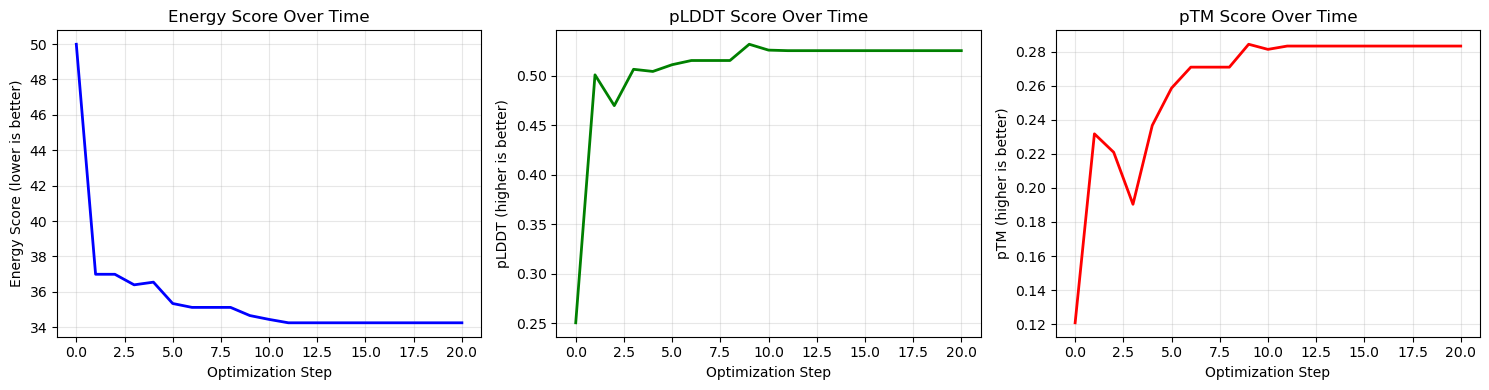


Optimization Summary:
Initial sequence: EWYQGGGHDQGWYGGGSRESDGERRYSKQA
Final sequence:   DRGRAPPARGPRAPRGRGGRAGGRGAGGPR
Energy improvement: 49.991 → 34.247
pLDDT improvement:  0.251 → 0.525
pTM improvement:    0.121 → 0.283

Final protein will form a 3-fold symmetric ring structure


In [ ]:
# Extract metrics from history - handle different metadata key formats
def get_metric(metadata, metric_name):
    """Get metric from metadata, handling suffixed keys."""
    if metric_name in metadata:
        return metadata[metric_name]
    for key in metadata.keys():
        if key.endswith(metric_name):
            return metadata[key]
    return None

energy_scores = [get_metric(c[0].joined_sequences[0]._metadata, 'energy_score') for c in optimizer.history]
plddt_scores = [get_metric(c[0].joined_sequences[0]._metadata, 'avg_plddt') for c in optimizer.history]
ptm_scores = [get_metric(c[0].joined_sequences[0]._metadata, 'ptm') for c in optimizer.history]

# Filter out None values for plotting
energy_scores = [e for e in energy_scores if e is not None]
plddt_scores = [p for p in plddt_scores if p is not None]
ptm_scores = [p for p in ptm_scores if p is not None]

# Plot optimization progress
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Energy score plot
if energy_scores:
    axes[0].plot(energy_scores, 'b-', linewidth=2)
    axes[0].set_title('Energy Score Over Time')
    axes[0].set_xlabel('Optimization Step')
    axes[0].set_ylabel('Energy Score (lower is better)')
    axes[0].grid(True, alpha=0.3)

# pLDDT score plot
if plddt_scores:
    axes[1].plot(plddt_scores, 'g-', linewidth=2)
    axes[1].set_title('pLDDT Score Over Time')
    axes[1].set_xlabel('Optimization Step')
    axes[1].set_ylabel('pLDDT (higher is better)')
    axes[1].grid(True, alpha=0.3)

# pTM score plot
if ptm_scores:
    axes[2].plot(ptm_scores, 'r-', linewidth=2)
    axes[2].set_title('pTM Score Over Time')
    axes[2].set_xlabel('Optimization Step')
    axes[2].set_ylabel('pTM (higher is better)')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nOptimization Summary:")
print(f"Initial sequence: {initial_construct.joined_sequences[0]._sequence}")
print(f"Final sequence:   {final_construct.joined_sequences[0]._sequence}")

if energy_scores:
    print(f"Energy improvement: {energy_scores[0]:.3f} → {energy_scores[-1]:.3f}")
if plddt_scores:
    print(f"pLDDT improvement:  {plddt_scores[0]:.3f} → {plddt_scores[-1]:.3f}")
if ptm_scores:
    print(f"pTM improvement:    {ptm_scores[0]:.3f} → {ptm_scores[-1]:.3f}")

print(f"\nFinal protein will form a {N_SYMMETRIC_UNITS}-fold symmetric ring structure")


In [ ]:
import py3Dmol

def visualize_structure_in_notebook(sequence: Sequence):
    """
    Visualize protein structure directly in Jupyter notebook using py3Dmol.
    This works without requiring PyMOL installation.
    """        
    if 'pdb_output' not in sequence._metadata:
        print("No PDB structure available in metadata")
        return None
    
    pdb_content = sequence._metadata['pdb_output']
    
    # Create 3D viewer
    viewer = py3Dmol.view(width=800, height=600)
    
    # Add the structure
    viewer.addModel(pdb_content, 'pdb')
    
    # Style the structure
    viewer.setStyle({'cartoon': {'color': 'spectrum'}})
    
    # If it's a multimer, color chains differently
    chains = set()
    for line in pdb_content.split('\n'):
        if line.startswith('ATOM'):
            chain = line[21]
            chains.add(chain)
    
    if len(chains) > 1:
        colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'cyan', 'magenta']
        for i, chain in enumerate(sorted(chains)):
            color = colors[i % len(colors)]
            viewer.setStyle({'chain': chain}, {'cartoon': {'color': color}})
    
    # Center and zoom
    viewer.zoomTo()
    
    plddt = get_metric(sequence._metadata, 'avg_plddt')
    ptm = get_metric(sequence._metadata, 'ptm')
    print(f"pLDDT: {plddt:.3f}" if plddt else "pLDDT: N/A")
    print(f"pTM: {ptm:.3f}" if ptm else "pTM: N/A")
    print(f"Sequence: {sequence.sequence}")
    return viewer


print("Initial Structure")
initial_viewer = visualize_structure_in_notebook(initial_construct.joined_sequences[0])
if initial_viewer:
    initial_viewer.show()

print("\nFinal Structure")
final_viewer = visualize_structure_in_notebook(final_construct.joined_sequences[0])
if final_viewer:
    final_viewer.show()

Initial Structure
pLDDT: 0.251
pTM: 0.121
Sequence: EWYQGGGHDQGWYGGGSRESDGERRYSKQA


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Final Structure
pLDDT: 0.525
pTM: 0.283
Sequence: DRGRAPPARGPRAPRGRGGRAGGRGAGGPR


3Dmol.js failed to load for some reason. Please check your browser console for error messages.